In [1]:
# Plot global pm2.5 mortality as a distribution, first and final 10 years, ensemble mean

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from utils.utils import autosize_figure, get_scenario_config

In [3]:
def load_global_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/pm25/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_first_decade_for_plotting(da):
    # Select the first 10 years
    da_first10 = da.isel(year=slice(0, 10))

    # Get the first and last time values
    start_time = da_first10.year[0].item()
    end_time = da_first10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_first10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [5]:
def process_final_decade_for_plotting(da):
    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))
    return da_mean, start_time, end_time

In [6]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/pm25/Global/"

model = "CESM2"
n_samples = 200

scenario1 = "SSP245_G6"
scenario2 = "G6-1.5K"

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1 = load_global_mortality_ensemble_members(model, scenario1, config1, n_samples)
da2 = load_global_mortality_ensemble_members(model, scenario2, config2, n_samples)

da1 = da1.sel(year=da2.year)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


In [7]:
# First 10 years
da1_mean, first_year1, last_year1 = process_first_decade_for_plotting(da1)
da2_mean, first_year2, last_year2 = process_first_decade_for_plotting(da2)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")

Years are the same


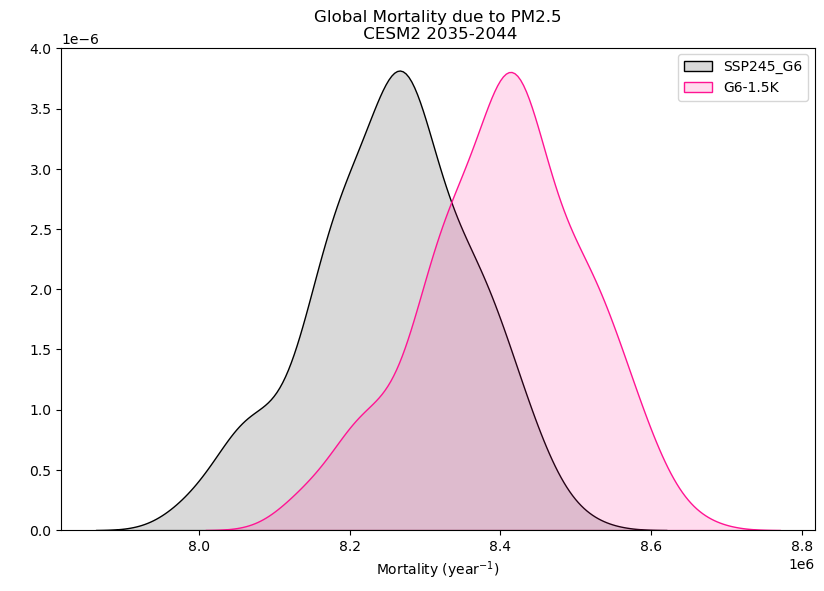

In [8]:
# Convert xarray to numpy
data1 = da1_mean.values
data2 = da2_mean.values

plt.figure(figsize=autosize_figure(1, 1))

# Plot using seaborn KDE
sns.kdeplot(data1, fill=True, label=scenario1, color="k", alpha=0.15)
sns.kdeplot(data2, fill=True, label=scenario2, color="deeppink", alpha=0.15)

plt.xlabel("Mortality (year$^{-1}$)")
plt.ylabel(" ")
plt.legend()
plt.title(f"Global Mortality due to PM2.5\n {model} {first_year2}-{last_year2}")

plt.tight_layout()

In [9]:
# Final 10 years
da1_mean, first_year1, last_year1 = process_final_decade_for_plotting(da1)
da2_mean, first_year2, last_year2 = process_final_decade_for_plotting(da2)

if first_year1 == first_year2 and last_year1 == last_year2:
    print("Years are the same")

Years are the same


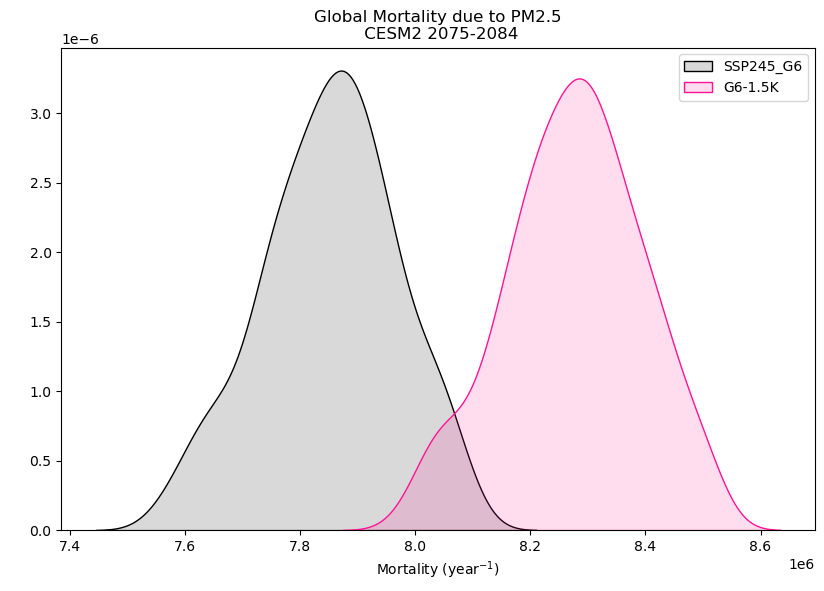

In [10]:
# Convert xarray to numpy
data1 = da1_mean.values
data2 = da2_mean.values

plt.figure(figsize=autosize_figure(1, 1))

# Plot using seaborn KDE
sns.kdeplot(data1, fill=True, label=scenario1, color="k", alpha=0.15)
sns.kdeplot(data2, fill=True, label=scenario2, color="deeppink", alpha=0.15)

plt.xlabel("Mortality (year$^{-1}$)")
plt.ylabel(" ")
plt.legend()
plt.title(f"Global Mortality due to PM2.5\n {model} {first_year1}-{last_year1}")

plt.tight_layout()

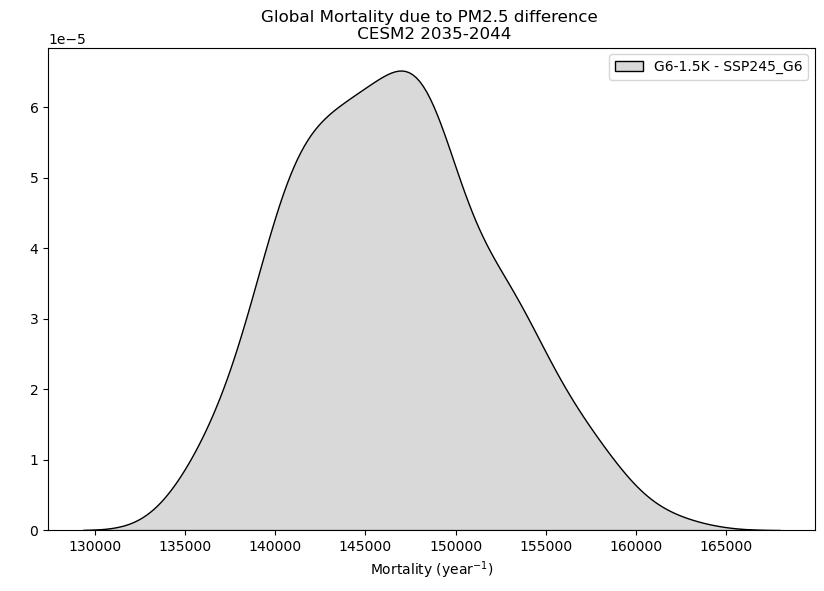

In [11]:
# Difference between scenarios
difference = da2 - da1  # SAI - noSAI

# First 10 years
mean, first_year, last_year = process_first_decade_for_plotting(difference)

# Convert xarray to numpy
data = mean.values

plt.figure(figsize=autosize_figure(1, 1))

# Plot using seaborn KDE
sns.kdeplot(data, fill=True, label=f"{scenario2} - {scenario1}", color="k", alpha=0.15)

plt.xlabel("Mortality (year$^{-1}$)")
plt.ylabel(" ")
plt.legend()
plt.title(f"Global Mortality due to PM2.5 difference \n {model} {first_year}-{last_year}")

plt.tight_layout()

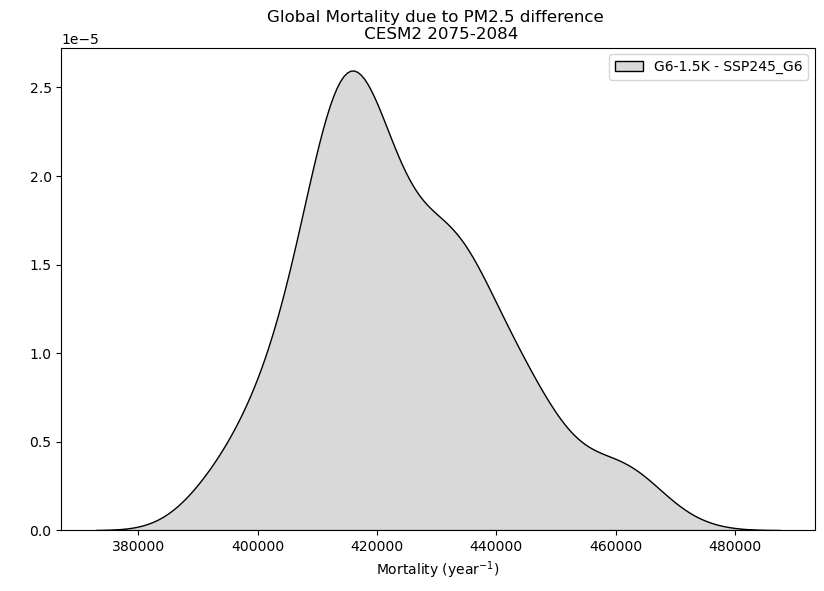

In [12]:
# Final 10 years
mean, first_year, last_year = process_final_decade_for_plotting(difference)

# Convert xarray to numpy
data = mean.values

plt.figure(figsize=autosize_figure(1, 1))

# Plot using seaborn KDE
sns.kdeplot(data, fill=True, label=f"{scenario2} - {scenario1}", color="k", alpha=0.15)

plt.xlabel("Mortality (year$^{-1}$)")
plt.ylabel(" ")
plt.legend()
plt.title(f"Global Mortality due to PM2.5 difference \n {model} {first_year}-{last_year}")

plt.tight_layout()